# 📦 Import Libraries
Let's bring in the tools we need for data analysis and visualization: pandas (for data), seaborn (for plots).

In [1]:
# import libraries
import pandas as pd
import seaborn as sns

# 📂 Load the Dataset
We load our perfume data from a CSV file so we can work with it in Python. Then, let's look at a random sample of 10 rows to get a feel for the data.

In [2]:
# load the dataset
df = pd.read_csv('../data_scraping/j_fragrances_men.csv')

# check the first few rows of the dataset
df.sample(10)

,name,price,image,rating,reviews
60,ZIYA SILVER ATTAR,"PKR 5,100.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN
21,OUDH QADIM,"PKR 5,000.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN
61,CLASSIQUE POUR HOMME | ADNAN SIDDIQUI,"PKR 6,700.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN
39,SHER DIL,"PKR 11,800.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN
88,ENIGMA - NO GAS POUR HOMME BODY SPRAY,PKR 800.00,https://www.junaidjamshed.com/static/version17...,NaN,NaN
51,DEEP BLUE,"PKR 1,800.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN
2,KHUMAR,"PKR 4,300.00",https://www.junaidjamshed.com/media/catalog/pr...,NaN,NaN
13,VOCAL,"PKR 7,000.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN
78,KHUMAR RED - 30ml,"PKR 2,400.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN
52,GOLD SHIMMER,"PKR 1,600.00",https://www.junaidjamshed.com/static/version17...,NaN,NaN


# 🧹 Clean the Price Column
The price column has symbols and text. We clean it to keep only numbers, so we can do math with it.

In [3]:
# Remove non-numeric characters and convert to float
df['price_clean'] = (
    df['price']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)  # Remove everything except digits and dot
    .replace('', None)
    .astype(float)
)

# 🕵️‍♂️ Check Dataset Info
Let's see what columns we have, how many rows and columns, and what type of data is in each column.

In [4]:
# check the columns of the dataset
print(f"{df.columns}\n")

# check the shape of the dataset
print(f'row = {df.shape[0]}, column = {df.shape[1]}\n')

# check the data types of the columns
print(f"{df.dtypes}\n")

Index(['name', 'price', 'image', 'rating', 'reviews', 'price_clean'], dtype='object')

row = 103, column = 6

name            object
price           object
image           object
rating         float64
reviews        float64
price_clean    float64
dtype: object



# 🧽 Remove Unneeded Columns
We drop the columns we don't need (like the original price, rating, and reviews) to keep our data tidy.

In [5]:
# remove the price column
df = df.drop(columns=['price','rating', 'reviews'])
df

,name,image,price_clean
0,WASIM AKRAM 502,https://www.junaidjamshed.com/media/catalog/pr...,5900.0
1,MIKA,https://www.junaidjamshed.com/media/catalog/pr...,3000.0
2,KHUMAR,https://www.junaidjamshed.com/media/catalog/pr...,4300.0
3,EDGE,https://www.junaidjamshed.com/media/catalog/pr...,5800.0
4,J.EXCLUSIVE,https://www.junaidjamshed.com/media/catalog/pr...,4300.0
...,...,...,...
98,HARMONIC RETREAT,https://www.junaidjamshed.com/static/version17...,2900.0
99,SERENE STROKES,https://www.junaidjamshed.com/static/version17...,2900.0
100,JANAN SPORT,https://www.junaidjamshed.com/static/version17...,6600.0
101,JANAN PLATINUM,https://www.junaidjamshed.com/static/version17...,6800.0


# 🕳️ Check for Missing Data
Let's see if any columns have missing (null) values. This helps us know if we need to clean more.

In [6]:
# check the null values in the dataset
print(f"{df.isnull().sum()}\n")

name           0
image          0
price_clean    0
dtype: int64



# 🏆 Show Perfume with Max and Min Price
Let's print the name and price of the most expensive and the cheapest perfume.

In [7]:
# print the maximum price of the perfume with name
max_price = df[df['price_clean'] == df['price_clean'].max()]
print(f"Max price perfume: {max_price['name'].values[0]} : Rs {max_price['price_clean'].values[0]}\n")

# print the minimum price of the perfume with name
min_price = df[df['price_clean'] == df['price_clean'].min()]
print(f"Min price perfume: {min_price['name'].values[0]} : Rs {min_price['price_clean'].values[0]}\n")

Max price perfume: WARRIOR POUR HOMME : Rs 19500.0

Min price perfume: STALLION POUR HOMME BODY SPRAY : Rs 650.0



# 🧪 Filter for 30ml Perfumes

To focus your analysis on only the 30ml perfume products, you can filter the DataFrame using the code below. This is useful for comparing prices, availability, or other features specific to the 30ml size.

In [16]:
df_30ml = df[df['name'].str.contains('30ml', na=False)]
df_30ml

,name,image,price_clean
32,JANAN OUD - 30ml,https://www.junaidjamshed.com/static/version17...,2800.0
37,ZARAR GOLD - 30ml,https://www.junaidjamshed.com/media/catalog/pr...,2200.0
40,KHUMAR - 30ml,https://www.junaidjamshed.com/static/version17...,2100.0
48,ZARAR BLEU - 30ml,https://www.junaidjamshed.com/static/version17...,2400.0
66,BLACK MUSK - 30ml,https://www.junaidjamshed.com/static/version17...,2200.0
78,KHUMAR RED - 30ml,https://www.junaidjamshed.com/static/version17...,2400.0


# 📊 Top 10 Most Expensive Perfumes
We make a colorful bar chart to show the 10 most expensive perfumes. The price is shown next to each bar.

C:\Users\touse\AppData\Local\Temp\ipykernel_9076\2389005484.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price_clean', y='name', data=df.nlargest(10, 'price_clean'), palette='plasma')


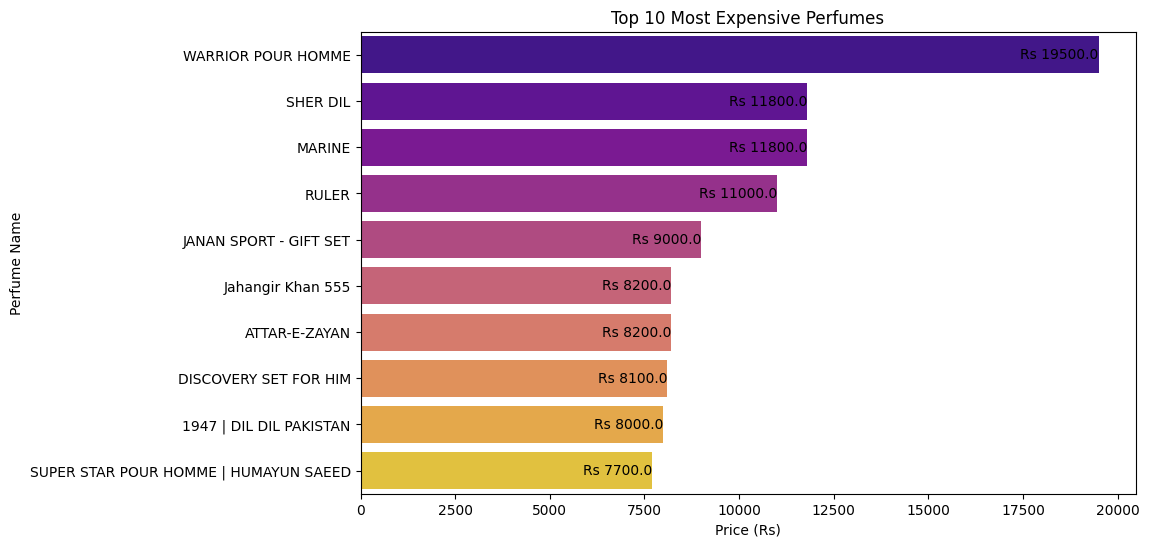

In [ ]:
# Create a bar plot of the top 10 perfumes with the highest price using mateplotlib
import matplotlib.pyplot as plt
# Set the figure size
plt.figure(figsize=(10, 6))
# Create a bar plot
sns.barplot(x='price_clean', y='name', data=df.nlargest(10, 'price_clean'), palette='plasma') 
# Set the title and labels
plt.title('Top 10 Most Expensive Perfumes')
plt.xlabel('Price (Rs)')
plt.ylabel('Perfume Name')
# add anotation
for index, value in enumerate(df.nlargest(10, 'price_clean')['price_clean']):
    plt.text(value, index, f'Rs {value}', va='center', ha='right', fontsize=10)
# Show the plot
plt.show()


# 📉 Top 10 Cheapest Perfumes
We make a colorful bar chart to show the 10 cheapest perfumes. The price is shown next to each bar.

C:\Users\touse\AppData\Local\Temp\ipykernel_9076\243611685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price_clean', y='name', data=df.nsmallest(10, 'price_clean'), palette='viridis')


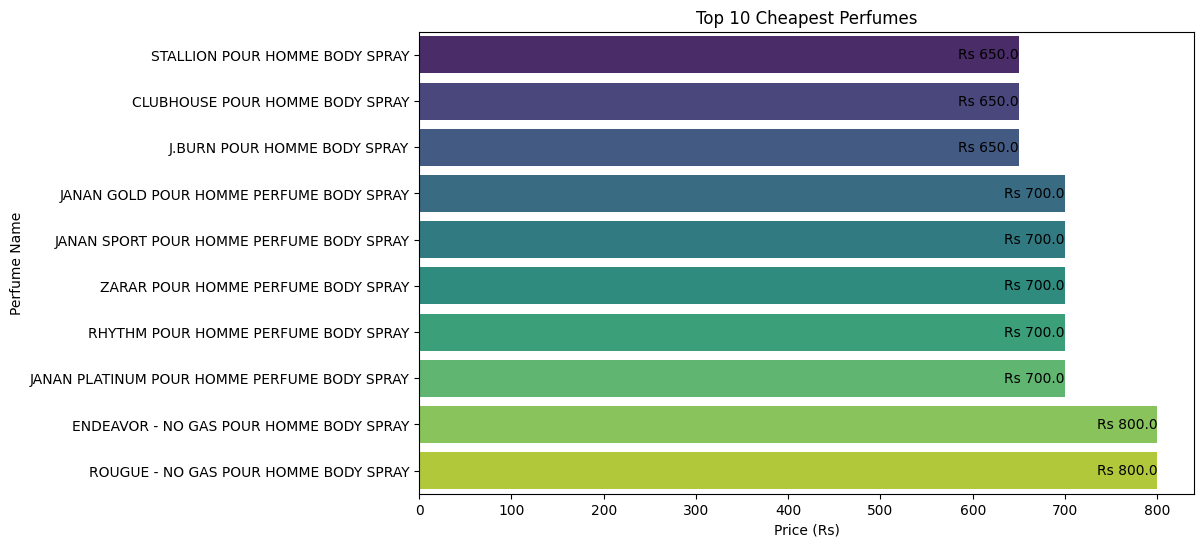

In [9]:
# create a bar plot of the top 10 perfumes with the lowest price using mateplotlib
# Set the figure size
plt.figure(figsize=(10, 6))
# Create a bar plot
sns.barplot(x='price_clean', y='name', data=df.nsmallest(10, 'price_clean'), palette='viridis')
# Set the title and labels
plt.title('Top 10 Cheapest Perfumes')
plt.xlabel('Price (Rs)')
plt.ylabel('Perfume Name')
# add anotation
for index, value in enumerate(df.nsmallest(10, 'price_clean')['price_clean']):
    plt.text(value, index, f'Rs {value}', va='center', ha='right', fontsize=10)
# Show the plot
plt.show()